# Eksperimen Machine Learning - Devin Novansyah
## Dataset: Titanic - Machine Learning from Disaster

Notebook ini berisi tahapan eksperimen awal sebelum dilakukan otomatisasi preprocessing.

### Tahapan:
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Simpan Data Hasil Preprocessing

---
## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Tampilan plot
plt.style.use('seaborn-v0_8')
%matplotlib inline

print('Library berhasil diimport!')

Library berhasil diimport!


---
## 2. Data Loading

In [2]:
# Load dataset Titanic
df = pd.read_csv('/content/train.csv')

print(f'Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')

Dataset berhasil dimuat!
Shape: (891, 12)
Jumlah baris: 891
Jumlah kolom: 12


In [3]:
# Tampilkan 5 baris pertama
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Tampilkan 5 baris terakhir
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
# Informasi tipe data dan non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Statistik deskriptif
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Cek Missing Values

In [7]:
# Hitung missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': missing_pct
}).sort_values('Missing Percentage (%)', ascending=False)

print('Missing Values per Kolom:')
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values per Kolom:
          Missing Count  Missing Percentage (%)
Cabin               687               77.104377
Age                 177               19.865320
Embarked              2                0.224467


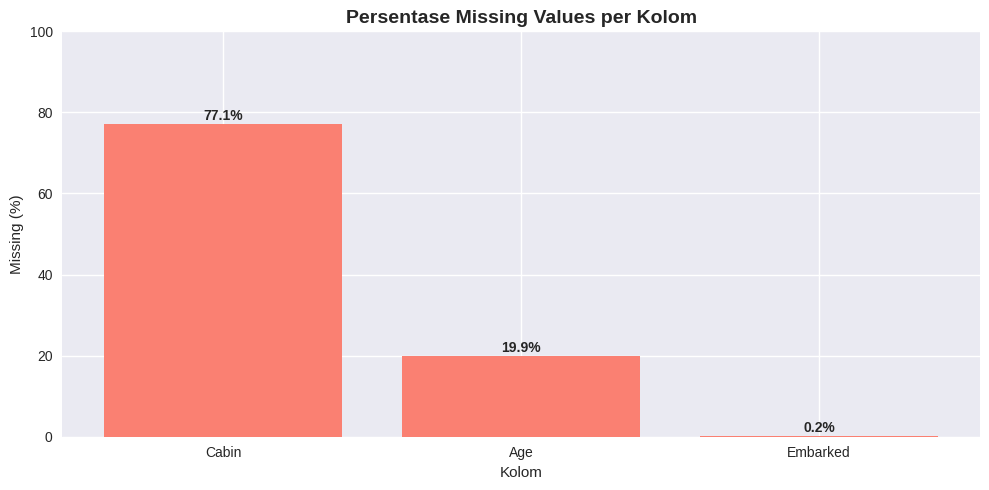

In [8]:
# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 5))
missing_cols = missing_df[missing_df['Missing Count'] > 0]
ax.bar(missing_cols.index, missing_cols['Missing Percentage (%)'], color='salmon')
ax.set_title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
ax.set_xlabel('Kolom')
ax.set_ylabel('Missing (%)')
ax.set_ylim(0, 100)
for i, v in enumerate(missing_cols['Missing Percentage (%)']):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Distribusi Target Variable (Survived)

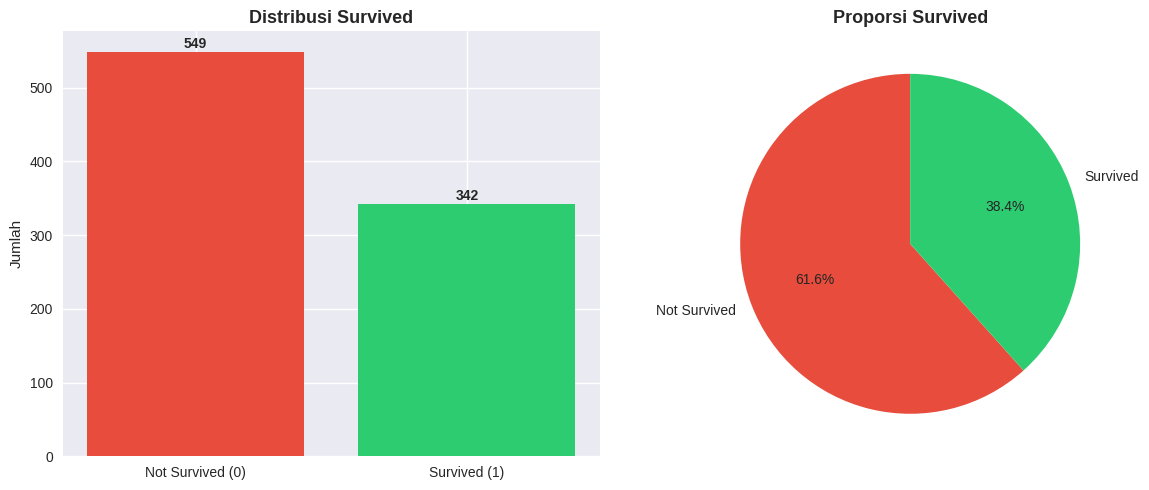

Not Survived: 549 (61.6%)
Survived: 342 (38.4%)


In [9]:
# Distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
survived_count = df['Survived'].value_counts()
axes[0].bar(['Not Survived (0)', 'Survived (1)'], survived_count.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribusi Survived', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(survived_count.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(survived_count.values, labels=['Not Survived', 'Survived'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Proporsi Survived', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Not Survived: {survived_count[0]} ({survived_count[0]/len(df)*100:.1f}%)')
print(f'Survived: {survived_count[1]} ({survived_count[1]/len(df)*100:.1f}%)')

### 3.3 Analisis Fitur Numerik

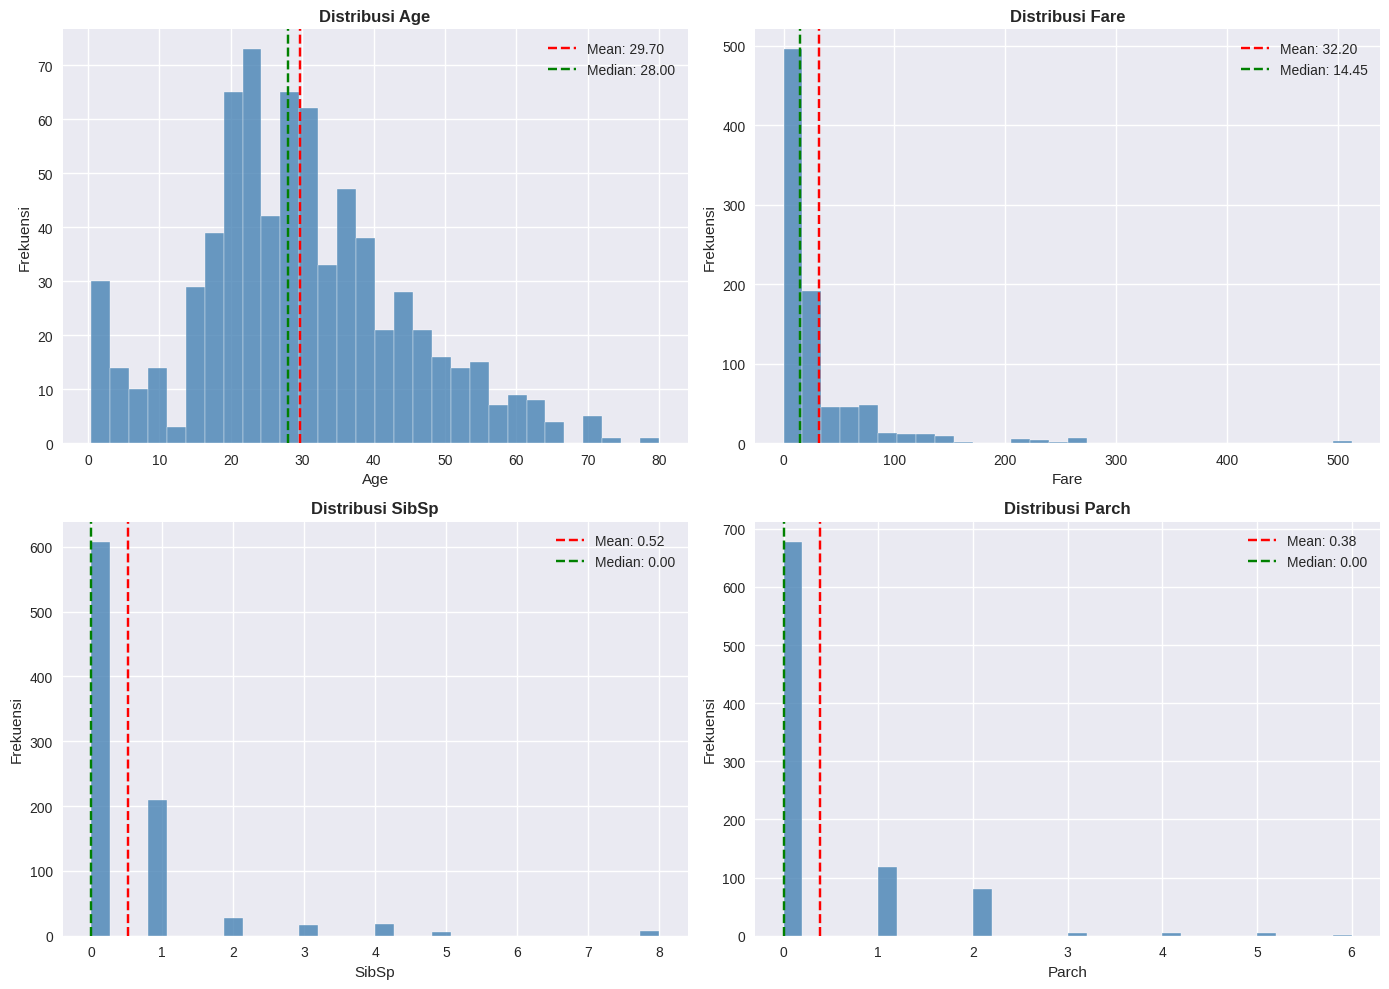

In [10]:
# Distribusi fitur numerik
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

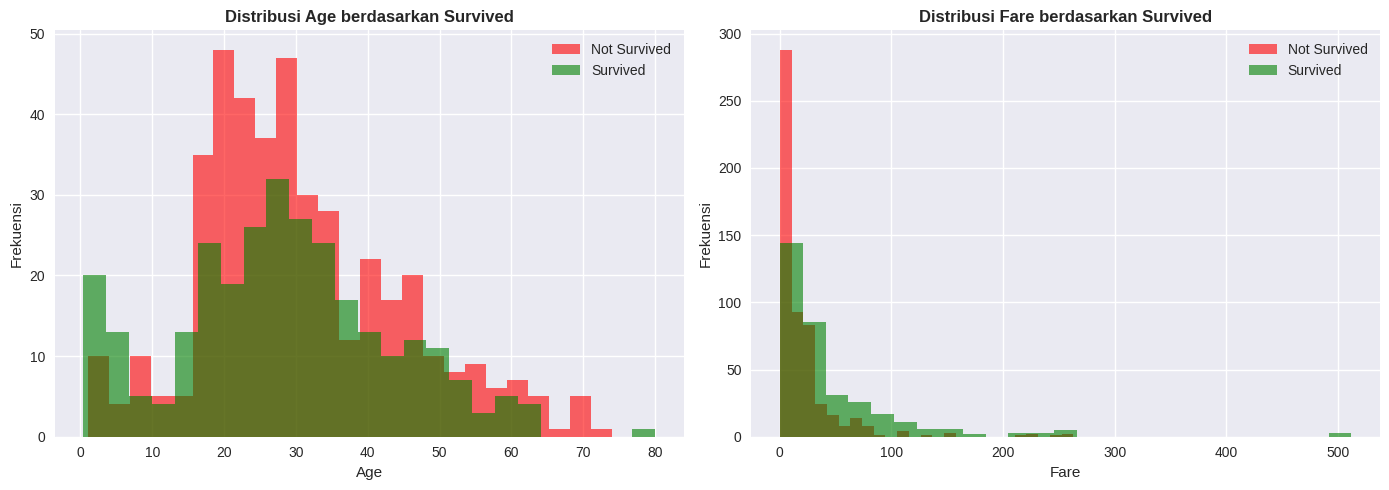

In [11]:
# Survival rate berdasarkan Age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by survived
df[df['Survived'] == 0]['Age'].dropna().hist(bins=25, ax=axes[0], alpha=0.6, color='red', label='Not Survived')
df[df['Survived'] == 1]['Age'].dropna().hist(bins=25, ax=axes[0], alpha=0.6, color='green', label='Survived')
axes[0].set_title('Distribusi Age berdasarkan Survived', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Fare distribution by survived
df[df['Survived'] == 0]['Fare'].hist(bins=25, ax=axes[1], alpha=0.6, color='red', label='Not Survived')
df[df['Survived'] == 1]['Fare'].hist(bins=25, ax=axes[1], alpha=0.6, color='green', label='Survived')
axes[1].set_title('Distribusi Fare berdasarkan Survived', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Analisis Fitur Kategorikal

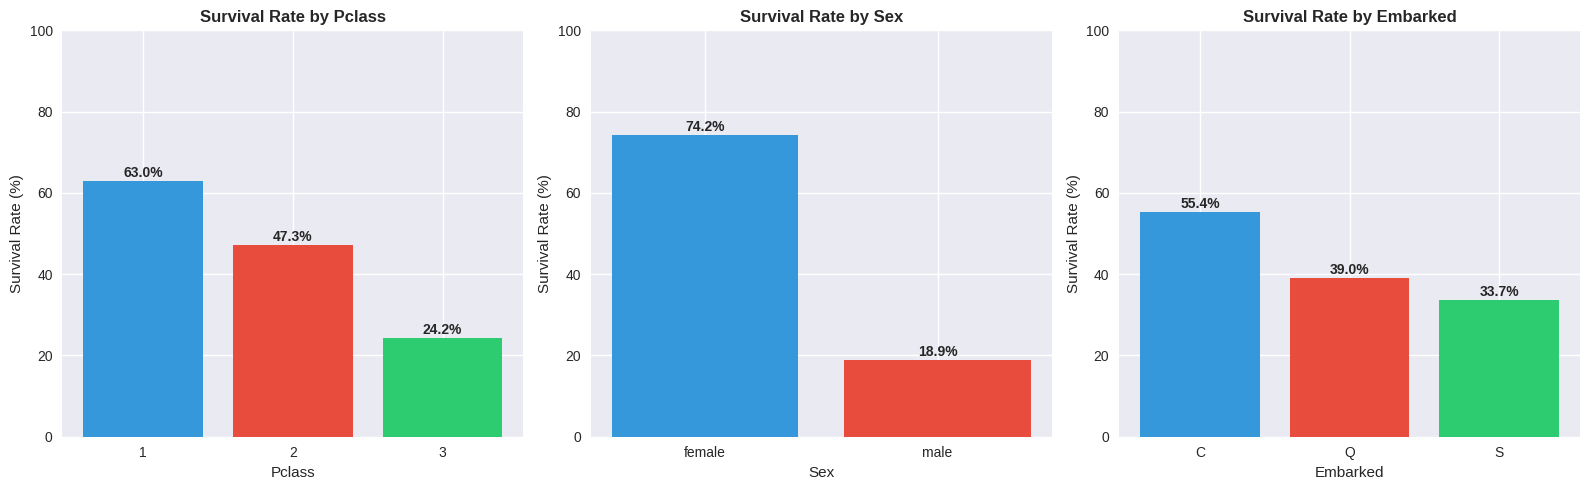

In [12]:
# Survival rate berdasarkan fitur kategorikal
cat_cols = ['Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    survival_rate = df.groupby(col)['Survived'].mean() * 100
    bars = axes[i].bar(survival_rate.index.astype(str), survival_rate.values,
                       color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'][:len(survival_rate)])
    axes[i].set_title(f'Survival Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Survival Rate (%)')
    axes[i].set_ylim(0, 100)
    for bar, val in zip(bars, survival_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 1,
                    f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap

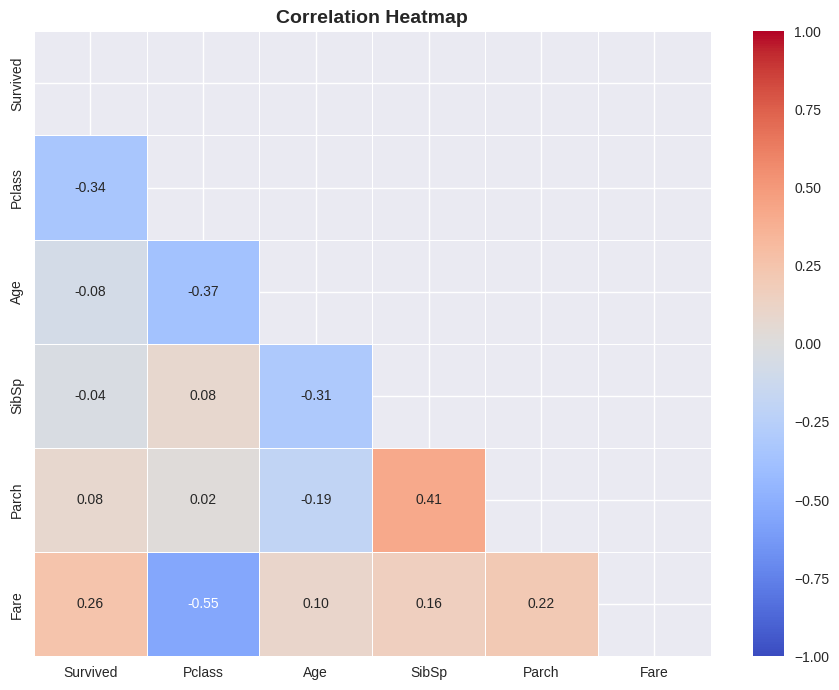

In [13]:
# Heatmap korelasi fitur numerik
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]

fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Outlier Detection

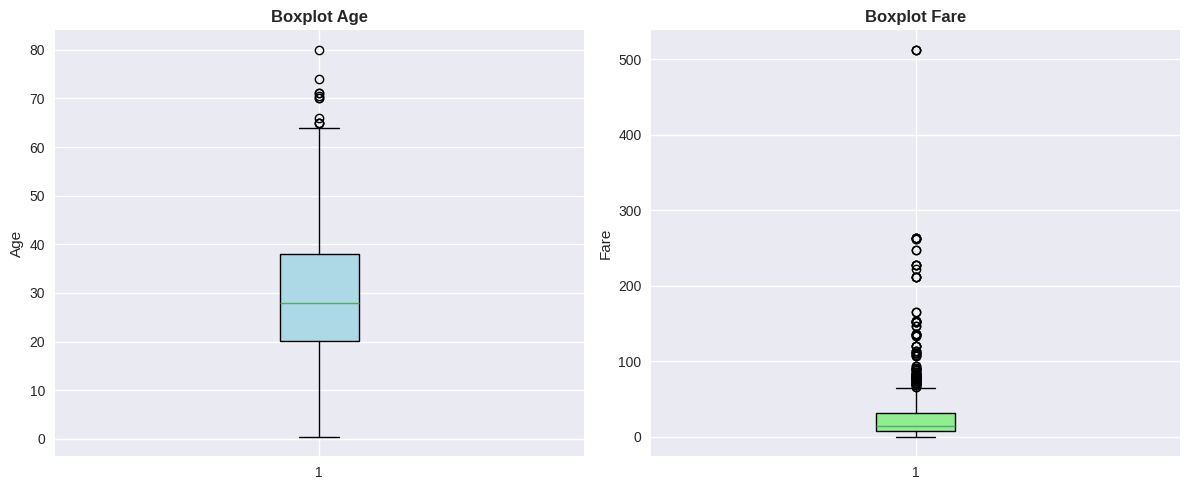

Age: 11 outlier terdeteksi (lower=-6.69, upper=64.81)
Fare: 116 outlier terdeteksi (lower=-26.72, upper=65.63)


In [14]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['Age'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Boxplot Age', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Age')

axes[1].boxplot(df['Fare'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Boxplot Fare', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fare')

plt.tight_layout()
plt.show()

# IQR method
for col in ['Age', 'Fare']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    print(f'{col}: {outliers} outlier terdeteksi (lower={lower:.2f}, upper={upper:.2f})')

---
## 4. Data Preprocessing

### 4.1 Seleksi Fitur

In [15]:
# Salin dataframe agar tidak mengubah data asli
df_processed = df.copy()

# Drop kolom yang tidak relevan
# PassengerId: hanya ID, tidak informatif
# Name: terlalu beragam (bisa diextract Title, tapi kita simplify)
# Ticket: tidak terstruktur
# Cabin: terlalu banyak missing values (77%)
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_processed = df_processed.drop(columns=cols_to_drop)

print(f'Kolom setelah seleksi: {df_processed.columns.tolist()}')
print(f'Shape: {df_processed.shape}')

Kolom setelah seleksi: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Shape: (891, 8)


### 4.2 Handling Missing Values

In [16]:
# Cek missing values sebelum
print('Missing values SEBELUM penanganan:')
print(df_processed.isnull().sum())

# Age: isi dengan median (robust terhadap outlier)
age_median = df_processed['Age'].median()
df_processed['Age'] = df_processed['Age'].fillna(age_median)
print(f'\nAge median (digunakan untuk imputasi): {age_median}')

# Embarked: isi dengan modus (paling sering muncul)
embarked_mode = df_processed['Embarked'].mode()[0]
df_processed['Embarked'] = df_processed['Embarked'].fillna(embarked_mode)
print(f'Embarked mode (digunakan untuk imputasi): {embarked_mode}')

print('\nMissing values SETELAH penanganan:')
print(df_processed.isnull().sum())

Missing values SEBELUM penanganan:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Age median (digunakan untuk imputasi): 28.0
Embarked mode (digunakan untuk imputasi): S

Missing values SETELAH penanganan:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### 4.3 Feature Engineering

In [17]:
# Buat fitur baru: FamilySize
df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1
print('Fitur FamilySize berhasil dibuat!')

# Buat fitur baru: IsAlone
df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)
print('Fitur IsAlone berhasil dibuat!')

# Buat kategori Age (AgeGroup)
df_processed['AgeGroup'] = pd.cut(df_processed['Age'],
                                   bins=[0, 12, 18, 35, 60, 100],
                                   labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
print('Fitur AgeGroup berhasil dibuat!')

df_processed.head()

Fitur FamilySize berhasil dibuat!
Fitur IsAlone berhasil dibuat!
Fitur AgeGroup berhasil dibuat!


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,0,3,male,22.0,1,0,7.2500,S,2,0,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,2,0,Adult
2,1,3,female,26.0,0,0,7.9250,S,1,1,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,2,0,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,1,1,Young Adult


### 4.4 Encoding Fitur Kategorikal

In [18]:
# Label Encoding untuk Sex
le = LabelEncoder()
df_processed['Sex'] = le.fit_transform(df_processed['Sex'])
print('Sex encoding: female=0, male=1')

# One-Hot Encoding untuk Embarked
embarked_dummies = pd.get_dummies(df_processed['Embarked'], prefix='Embarked', drop_first=True)
df_processed = pd.concat([df_processed, embarked_dummies], axis=1)
df_processed = df_processed.drop(columns=['Embarked'])
print('Embarked berhasil di-encode (One-Hot)')

# One-Hot Encoding untuk AgeGroup
agegroup_dummies = pd.get_dummies(df_processed['AgeGroup'], prefix='AgeGroup', drop_first=True)
df_processed = pd.concat([df_processed, agegroup_dummies], axis=1)
df_processed = df_processed.drop(columns=['AgeGroup'])
print('AgeGroup berhasil di-encode (One-Hot)')

print(f'\nShape setelah encoding: {df_processed.shape}')
print(f'Kolom: {df_processed.columns.tolist()}')

Sex encoding: female=0, male=1
Embarked berhasil di-encode (One-Hot)
AgeGroup berhasil di-encode (One-Hot)

Shape setelah encoding: (891, 15)
Kolom: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior']


### 4.5 Feature Scaling

In [19]:
# Standardisasi fitur numerik
scaler = StandardScaler()
cols_to_scale = ['Age', 'Fare', 'FamilySize']

df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

print('Feature scaling berhasil!')
print(f'Fitur yang di-scale: {cols_to_scale}')
df_processed[cols_to_scale].describe()

Feature scaling berhasil!
Fitur yang di-scale: ['Age', 'Fare', 'FamilySize']


,Age,Fare,FamilySize
count,8.910000e+02,8.910000e+02,8.910000e+02
mean,2.272780e-16,3.987333e-18,-2.392400e-17
std,1.000562e+00,1.000562e+00,1.000562e+00
min,-2.224156e+00,-6.484217e-01,-5.609748e-01
25%,-5.657365e-01,-4.891482e-01,-5.609748e-01
50%,-1.046374e-01,-3.573909e-01,-5.609748e-01
75%,4.333115e-01,-2.424635e-02,5.915988e-02
max,3.891554e+00,9.667167e+00,5.640372e+00


### 4.6 Cek Data Akhir

In [20]:
# Tampilkan data hasil preprocessing
print('=== DATA HASIL PREPROCESSING ===')
print(f'Shape: {df_processed.shape}')
print(f'Missing values: {df_processed.isnull().sum().sum()}')
print(f'Kolom: {df_processed.columns.tolist()}')
print()
df_processed.head()

=== DATA HASIL PREPROCESSING ===
Shape: (891, 15)
Missing values: 0
Kolom: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior']



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior
0,0,3,1,-0.565736,1,0,-0.502445,0.059160,0,False,True,False,True,False,False
1,1,1,0,0.663861,1,0,0.786845,0.059160,0,False,False,False,False,True,False
2,1,3,0,-0.258337,0,0,-0.488854,-0.560975,1,False,True,False,True,False,False
3,1,1,0,0.433312,1,0,0.420730,0.059160,0,False,True,False,True,False,False
4,0,3,1,0.433312,0,0,-0.486337,-0.560975,1,False,True,False,True,False,False


In [21]:
# Pastikan semua tipe data sudah numerik
print('Tipe data:')
print(df_processed.dtypes)

Tipe data:
Survived                  int64
Pclass                    int64
Sex                       int64
Age                     float64
SibSp                     int64
Parch                     int64
Fare                    float64
FamilySize              float64
IsAlone                   int64
Embarked_Q                 bool
Embarked_S                 bool
AgeGroup_Teen              bool
AgeGroup_Young Adult       bool
AgeGroup_Adult             bool
AgeGroup_Senior            bool
dtype: object


---
## 5. Simpan Hasil Preprocessing

In [22]:
import os

# Simpan hasil preprocessing
output_path = 'titanic_preprocessing/train_preprocessed.csv'
os.makedirs('titanic_preprocessing', exist_ok=True)
df_processed.to_csv(output_path, index=False)

print(f'✅ Data berhasil disimpan ke: {output_path}')
print(f'   Shape: {df_processed.shape}')
print(f'   Kolom: {df_processed.columns.tolist()}')

✅ Data berhasil disimpan ke: titanic_preprocessing/train_preprocessed.csv
   Shape: (891, 15)
   Kolom: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior']


---
## 6. Ringkasan Preprocessing

| Tahap | Keterangan |
|-------|------------|
| **Seleksi Fitur** | Drop kolom: PassengerId, Name, Ticket, Cabin |
| **Handling Missing** | Age → median, Embarked → modus |
| **Feature Engineering** | FamilySize, IsAlone, AgeGroup |
| **Encoding** | Sex (Label Enc), Embarked & AgeGroup (One-Hot Enc) |
| **Scaling** | Age, Fare, FamilySize → StandardScaler |
| **Output** | `titanic_preprocessing/train_preprocessed.csv` |